In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

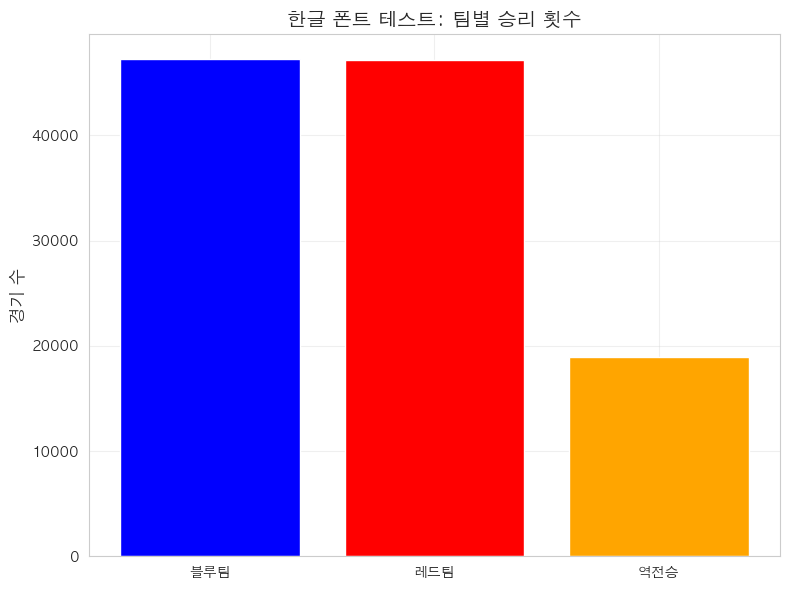

✅ 한글이 정상적으로 표시되면 OK!
❌ 깨지면 아래 명령어로 폰트 설치:
   brew install --cask font-nanum


In [2]:
plt.rcParams['font.family'] = 'AppleGothic'  # macOS 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
"""
한글 폰트 테스트 코드 (macOS)
"""

import matplotlib.pyplot as plt

# 폰트 설정 테스트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 간단한 그래프
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(['블루팀', '레드팀', '역전승'], [47234, 47121, 18923], color=['blue', 'red', 'orange'])
ax.set_title('한글 폰트 테스트: 팀별 승리 횟수', fontsize=14, fontweight='bold')
ax.set_ylabel('경기 수', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ 한글이 정상적으로 표시되면 OK!")
print("❌ 깨지면 아래 명령어로 폰트 설치:")
print("   brew install --cask font-nanum")

In [3]:
df= pd.read_csv("final.csv")
drop = [
    "matchId",
]

df.drop(drop, axis=1, inplace=True)

bool_columns = [
    'blueWins',
    'blueFirstBlood', 'redFirstBlood',
    'blueFirstTurret', 'redFirstTurret',
    'blueFirstDragon', 'redFirstDragon'
]

for col in bool_columns:
    if col in df.columns:
        df[col] = df[col].astype(bool)

df[['blueWins']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94355 entries, 0 to 94354
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   blueWins  94355 non-null  bool 
dtypes: bool(1)
memory usage: 92.3 KB


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94355 entries, 0 to 94354
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   blueWins                      94355 non-null  bool   
 1   blueWardsPlaced               94355 non-null  int64  
 2   blueControlWardsPlaced        94355 non-null  int64  
 3   blueWardsDestroyed            94355 non-null  int64  
 4   blueControlWardsDestroyed     94355 non-null  int64  
 5   blueFirstBlood                94355 non-null  bool   
 6   blueKills                     94355 non-null  int64  
 7   blueDeaths                    94355 non-null  int64  
 8   blueAssists                   94355 non-null  int64  
 9   blueDragons                   94355 non-null  int64  
 10  blueHeralds                   94355 non-null  int64  
 11  blueVoidGrubs                 94355 non-null  int64  
 12  blueTowersDestroyed           94355 non-null  int64  
 13  b

--- 블루팀 지표 상관관계 히트맵 ---


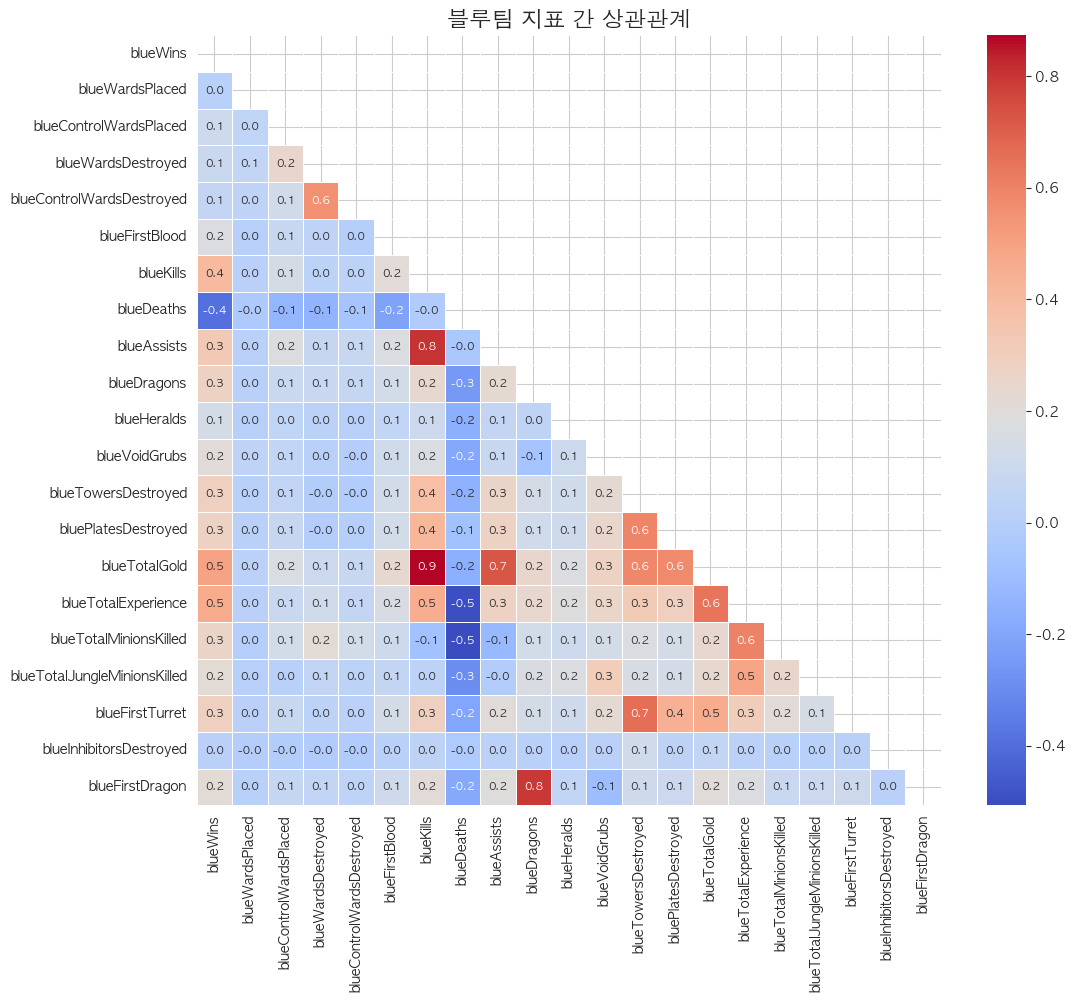


--- 레드팀 지표 상관관계 히트맵 ---


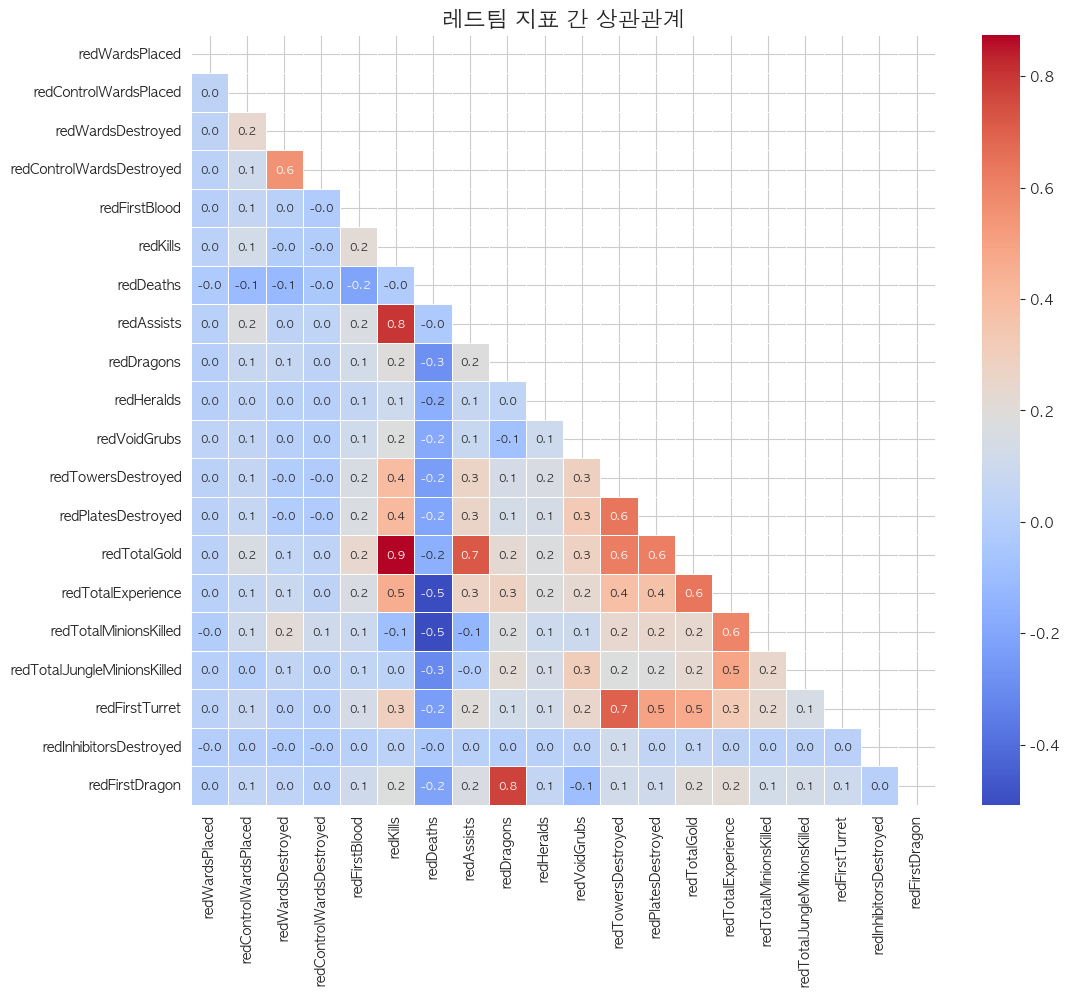

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 블루팀 지표 상관관계 히트맵 ---")
blue_cols = [col for col in df.columns if 'blue' in col]
blue_corr_matrix = df[blue_cols].corr()
mask_blue = np.triu(np.ones_like(blue_corr_matrix, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(blue_corr_matrix, mask=mask_blue, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5, annot_kws={"size": 8})
plt.title('블루팀 지표 간 상관관계', fontsize=16, fontweight='bold')
plt.show()


print("\n--- 레드팀 지표 상관관계 히트맵 ---")
red_cols = [col for col in df.columns if 'red' in col]
red_corr_matrix = df[red_cols].corr()
mask_red = np.triu(np.ones_like(red_corr_matrix, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(red_corr_matrix, mask=mask_red, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5, annot_kws={"size": 8})
plt.title('레드팀 지표 간 상관관계', fontsize=16, fontweight='bold')
plt.show()



--- 블루팀 지표와 승리 상관관계 히트맵 ---


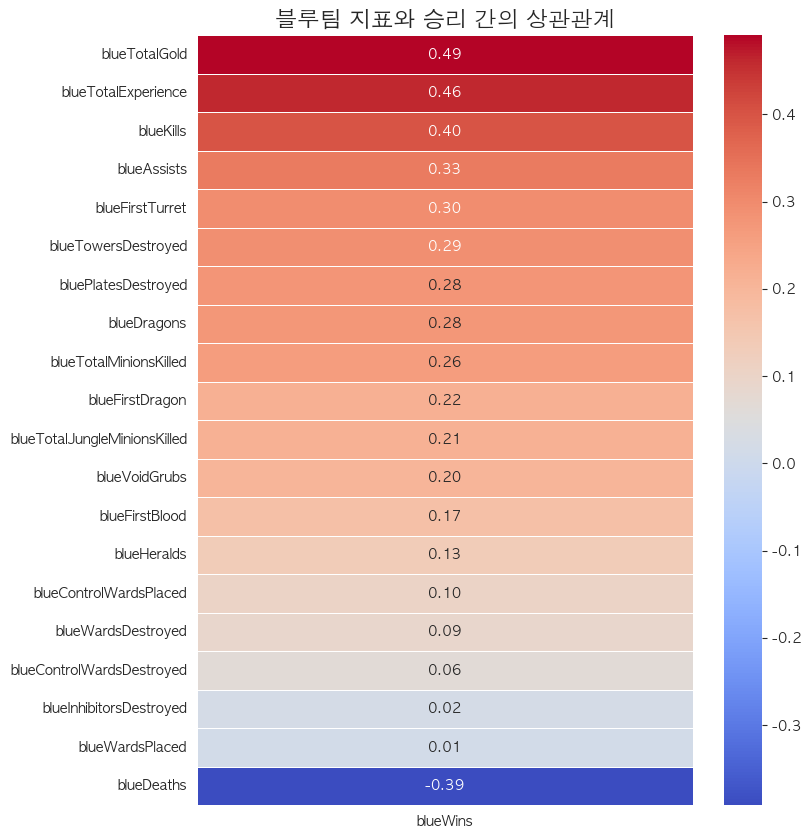


--- 레드팀 지표와 승리 상관관계 히트맵 ---


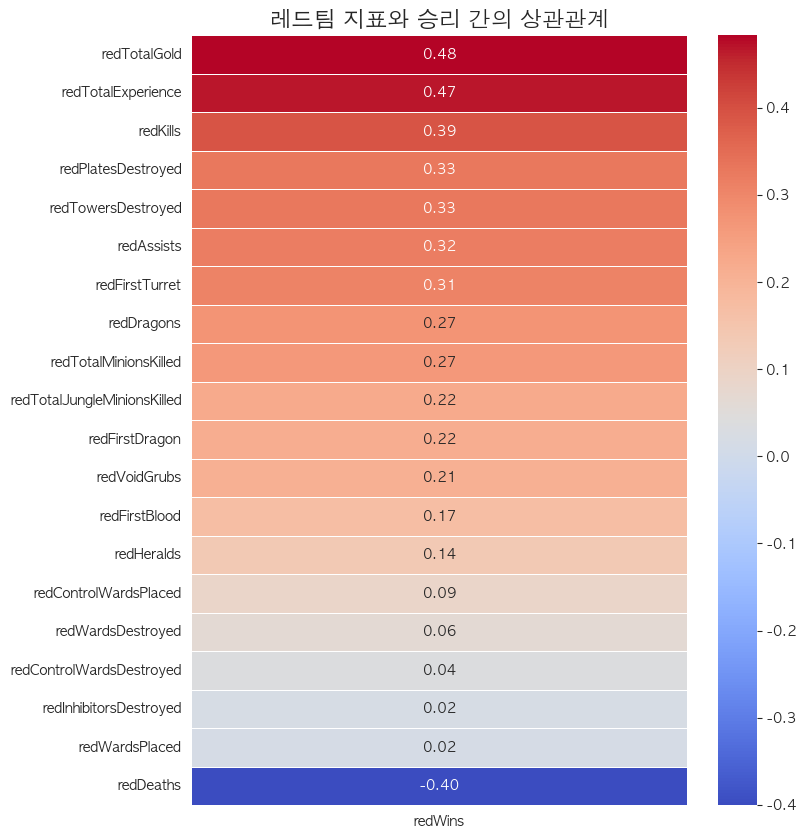

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 블루팀 지표와 승리 상관관계 히트맵 ---")
blue_cols = [col for col in df.columns if 'blue' in col]
blue_corr = df[blue_cols].corr()[['blueWins']].sort_values(by='blueWins', ascending=False)
blue_corr_filtered = blue_corr.drop('blueWins')
plt.figure(figsize=(8, 10))
sns.heatmap(blue_corr_filtered, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('블루팀 지표와 승리 간의 상관관계', fontsize=16, fontweight='bold')
plt.savefig('blue_team_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- 레드팀 지표와 승리 상관관계 히트맵 ---")
red_cols_with_wins = ['blueWins'] + [col for col in df.columns if 'red' in col]
red_corr_raw = df[red_cols_with_wins].corr()[['blueWins']]
red_corr = (red_corr_raw * -1).rename(columns={'blueWins': 'redWins'}).sort_values(by='redWins', ascending=False)
red_corr_filtered = red_corr.drop('blueWins')
plt.figure(figsize=(8, 10))
sns.heatmap(red_corr_filtered, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('레드팀 지표와 승리 간의 상관관계', fontsize=16, fontweight='bold')
plt.savefig('red_team_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



--- 분석 1: 승리팀 vs 패배팀 평균 지표 차이 ---


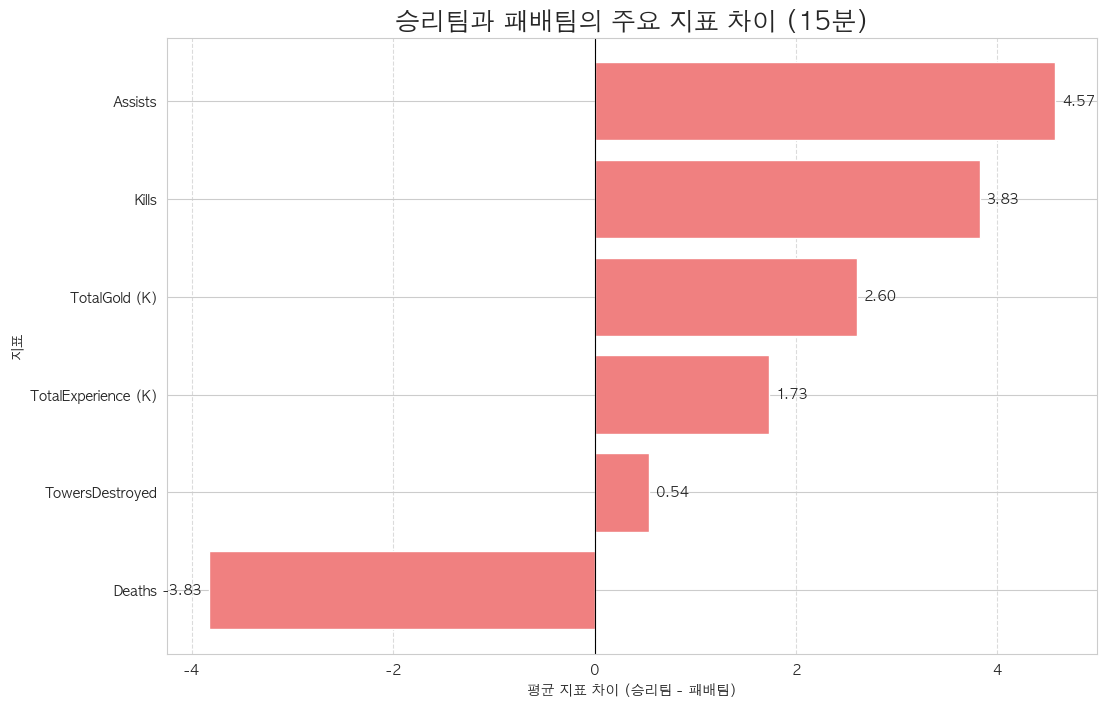


--- 분석 2: 골드 및 킬 격차에 따른 승률 변화 ---


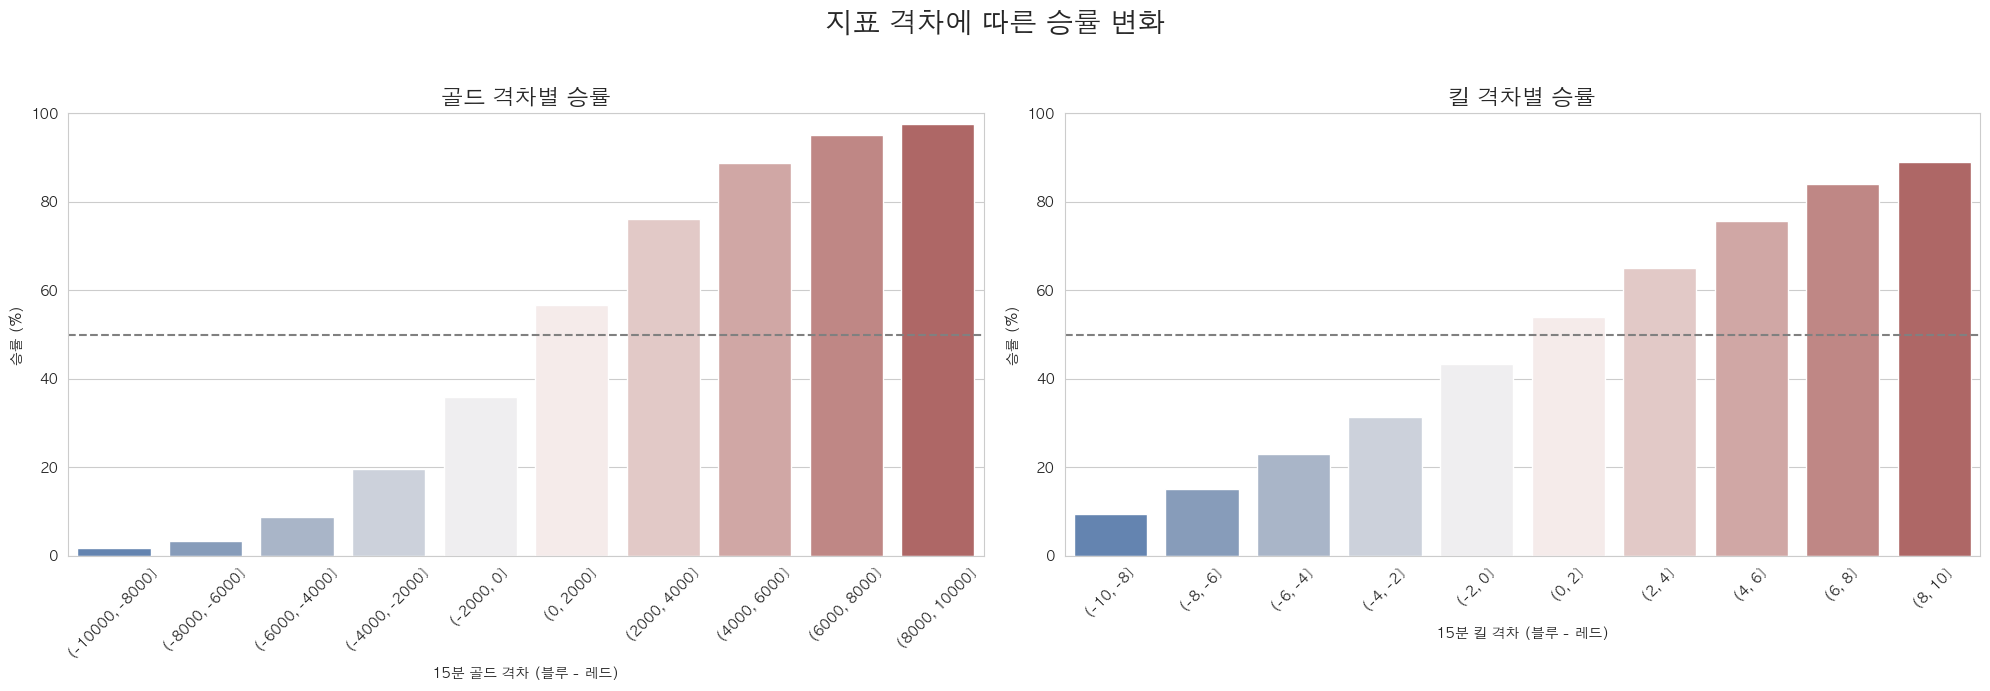


--- 분석 3: 첫 주요 오브젝트 획득 시 승률 ---


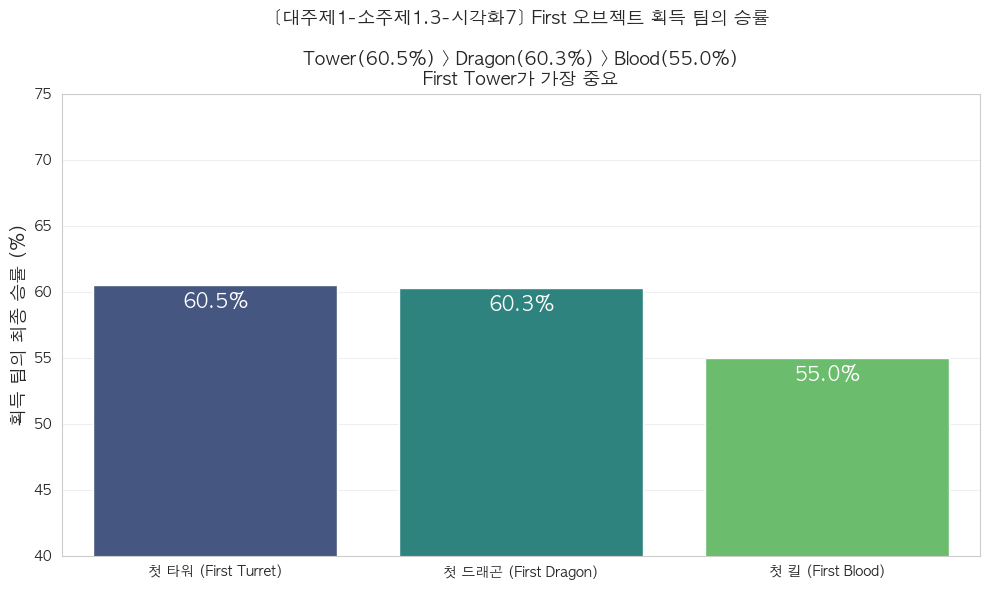


--- 분석 4: 타워 격차에 따른 승률 비교 ---


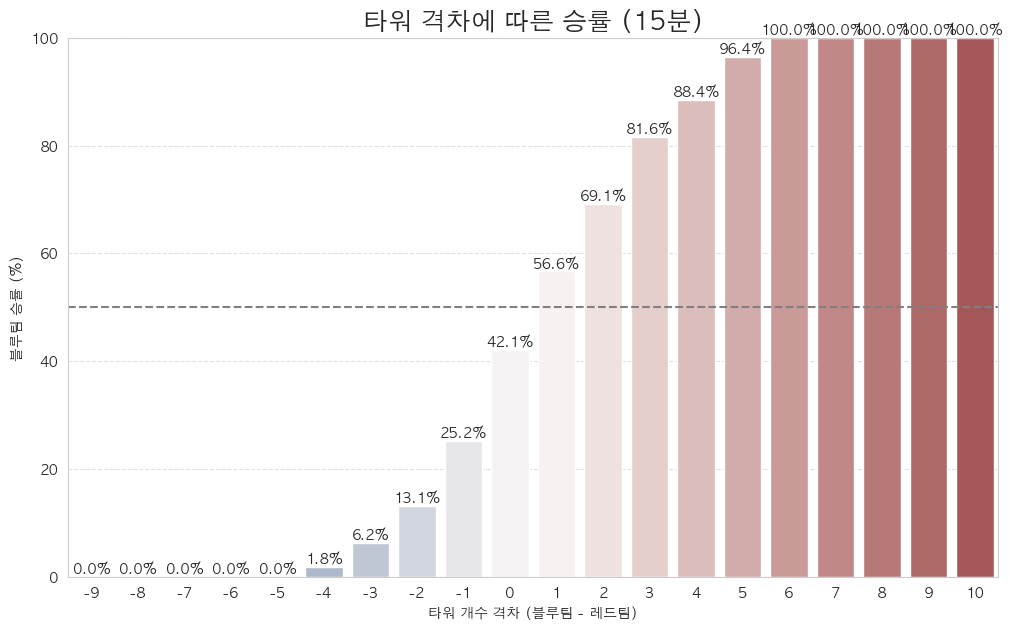

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("--- 분석 1: 승리팀 vs 패배팀 평균 지표 차이 ---")
metrics = [
    'Kills', 'Deaths', 'Assists', 'TotalGold', 'TotalExperience',
    'TowersDestroyed'
]

win_team_metrics = [f'blue{stat}' for stat in metrics]
lose_team_metrics = [f'red{stat}' for stat in metrics]
win_as_blue = df.loc[df['blueWins'] == True, win_team_metrics]
lose_as_red = df.loc[df['blueWins'] == True, lose_team_metrics]
win_as_blue.columns = lose_as_red.columns = metrics
lose_team_metrics_rev = [f'blue{stat}' for stat in metrics]
win_team_metrics_rev = [f'red{stat}' for stat in metrics]
lose_as_blue = df.loc[df['blueWins'] == False, lose_team_metrics_rev]
win_as_red = df.loc[df['blueWins'] == False, win_team_metrics_rev]
lose_as_blue.columns = win_as_red.columns = metrics
total_win_stats = pd.concat([win_as_blue, win_as_red])
total_lose_stats = pd.concat([lose_as_red, lose_as_blue])


diff_stats = total_win_stats.mean() - total_lose_stats.mean()
diff_df = pd.DataFrame({'Difference': diff_stats})
# 골드와 경험치는 단위가 커서 1000으로 나누어 K 단위로 표시합니다.
diff_df.loc['TotalGold', 'Difference'] /= 1000
diff_df.loc['TotalExperience', 'Difference'] /= 1000

diff_df = diff_df.rename(index={'TotalGold': 'TotalGold (K)', 'TotalExperience': 'TotalExperience (K)'})
diff_df = diff_df.sort_values('Difference', ascending=True)
colors = ['cornflowerblue' if x > 0 else 'lightcoral' for x in diff_df['Difference']]

ax = diff_df.plot(kind='barh', figsize=(12, 8), color=colors, legend=False, width=0.8)
plt.title('승리팀과 패배팀의 주요 지표 차이 (15분)', fontsize=18, fontweight='bold')
plt.xlabel('평균 지표 차이 (승리팀 - 패배팀)')
plt.ylabel('지표')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='black', linewidth=0.8)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5, fontsize=10)

plt.show()


print("\n--- 분석 2: 골드 및 킬 격차에 따른 승률 변화 ---")


gold_diff = df['blueTotalGold'] - df['redTotalGold']
kill_diff = df['blueKills'] - df['redKills']

gold_bins = pd.cut(gold_diff, bins=np.arange(-10000, 10001, 2000))
kill_bins = pd.cut(kill_diff, bins=np.arange(-10, 11, 2))

gold_win_rate = df.groupby(gold_bins)['blueWins'].mean() * 100
kill_win_rate = df.groupby(kill_bins)['blueWins'].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('지표 격차에 따른 승률 변화', fontsize=20, fontweight='bold')

sns.barplot(x=gold_win_rate.index.astype(str), y=gold_win_rate.values, ax=ax1, palette='vlag')
ax1.set_title('골드 격차별 승률', fontsize=16)
ax1.set_xlabel('15분 골드 격차 (블루 - 레드)')
ax1.set_ylabel('승률 (%)')
ax1.axhline(50, color='grey', linestyle='--')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(0, 100)

sns.barplot(x=kill_win_rate.index.astype(str), y=kill_win_rate.values, ax=ax2, palette='vlag')
ax2.set_title('킬 격차별 승률', fontsize=16)
ax2.set_xlabel('15분 킬 격차 (블루 - 레드)')
ax2.set_ylabel('승률 (%)')
ax2.axhline(50, color='grey', linestyle='--')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0, 100)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n--- 분석 3: 첫 주요 오브젝트 획득 시 승률 ---")
first_blood_win = df.groupby('blueFirstBlood')['blueWins'].mean()[1] * 100
first_tower_win = df.groupby('blueFirstTurret')['blueWins'].mean()[1] * 100
first_dragon_win = df.groupby('blueFirstDragon')['blueWins'].mean()[1] * 100

first_obj_win_rates = pd.DataFrame({
    'Objective': ['첫 킬 (First Blood)', '첫 타워 (First Turret)', '첫 드래곤 (First Dragon)'],
    'Win Rate': [first_blood_win, first_tower_win, first_dragon_win]
}).sort_values('Win Rate', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Objective', y='Win Rate', data=first_obj_win_rates, palette='viridis')

ax.set_title(f'[대주제1-소주제1.3-시각화7] First 오브젝트 획득 팀의 승률\n\n'
             f'Tower({first_tower_win:.1f}%) > Dragon({first_dragon_win:.1f}%) > Blood({first_blood_win:.1f}%)\n'
             f'First Tower가 가장 중요',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('획득 팀의 최종 승률 (%)', fontsize=13)
ax.set_ylim(40, 75)
ax.grid(alpha=0.3, axis='y')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, -12),
                   textcoords = 'offset points',
                   color='white',
                   fontsize=14)
                   
plt.tight_layout()
plt.show()

print("\n--- 분석 4: 타워 격차에 따른 승률 비교 ---")
tower_diff = df['blueTowersDestroyed'] - df['redTowersDestroyed']
tower_diff_win_rate = df.groupby(tower_diff)['blueWins'].mean() * 100
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=tower_diff_win_rate.index, y=tower_diff_win_rate.values, palette='vlag')
ax.set_title('타워 격차에 따른 승률 (15분)', fontsize=18, fontweight='bold')
ax.set_xlabel('타워 개수 격차 (블루팀 - 레드팀)')
ax.set_ylabel('블루팀 승률 (%)')
ax.set_ylim(0, 100)
ax.axhline(50, color='grey', linestyle='--')
ax.grid(axis='y', linestyle='--', alpha=0.6)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 5),
                   textcoords = 'offset points',
                   fontsize=10)

plt.show()



--- 1-1. 역전승 비율 분석 ---


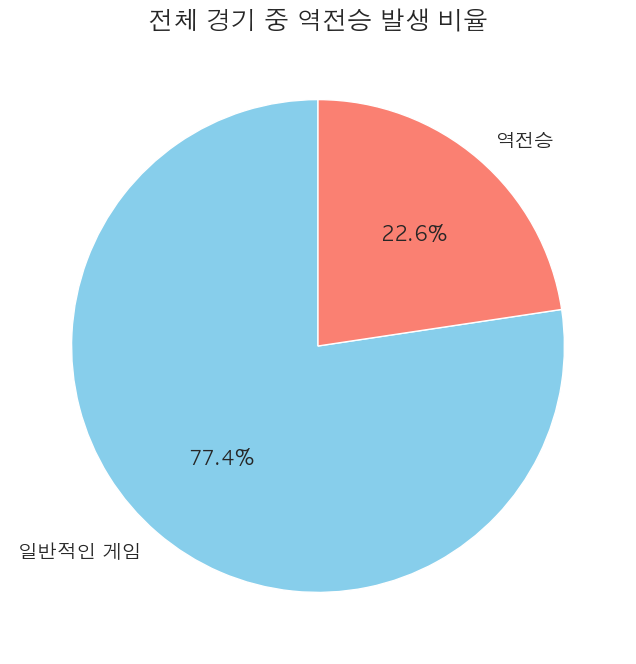


--- 1-2. 골드 격차에 따른 역전 확률 ---


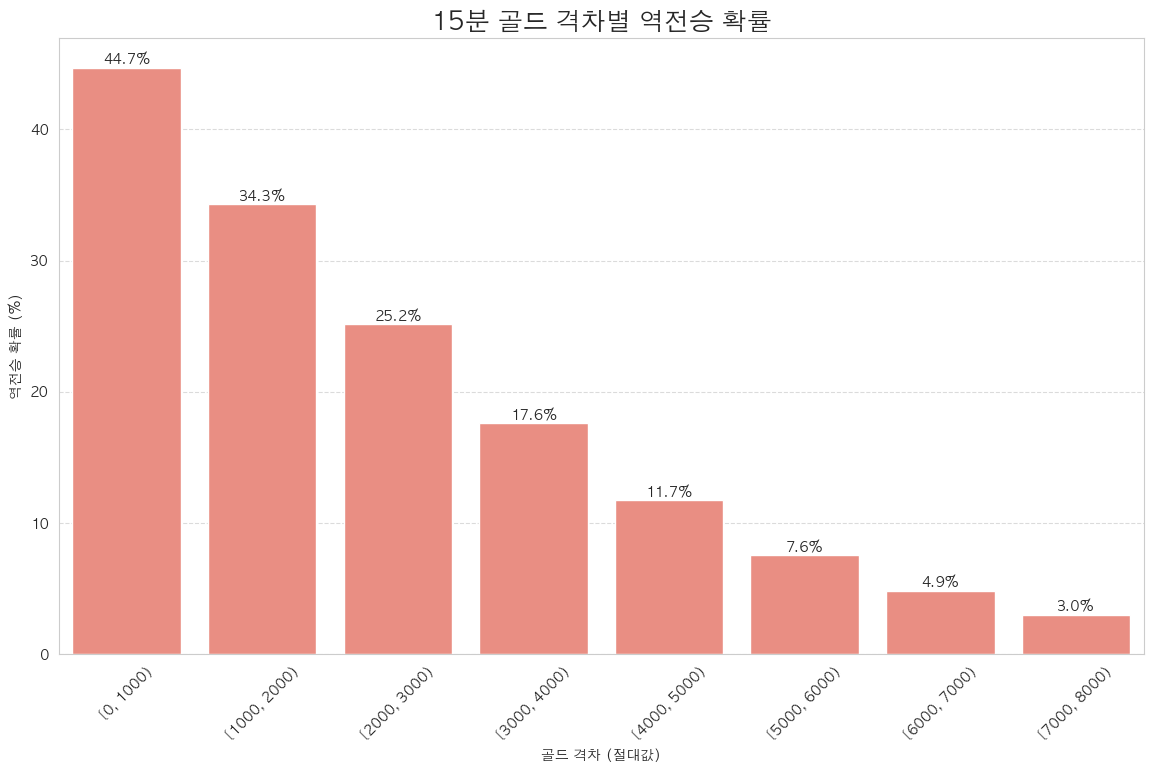


--- 1-3. 역전승 팀의 평균 열세 정도 ---


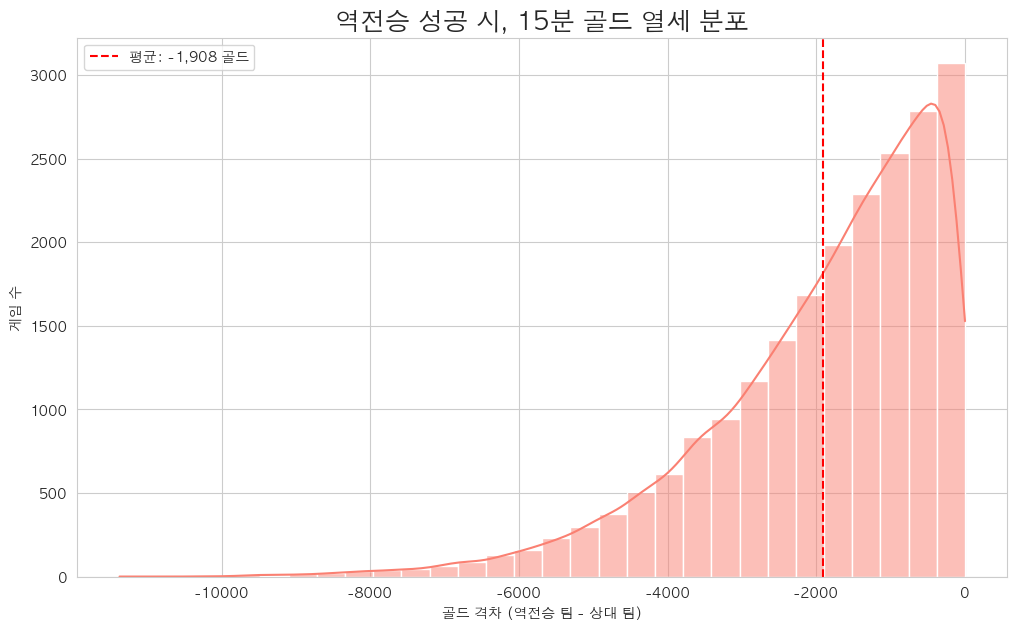


--- 2. 승리 유형별 주요 지표 평균 비교 ---


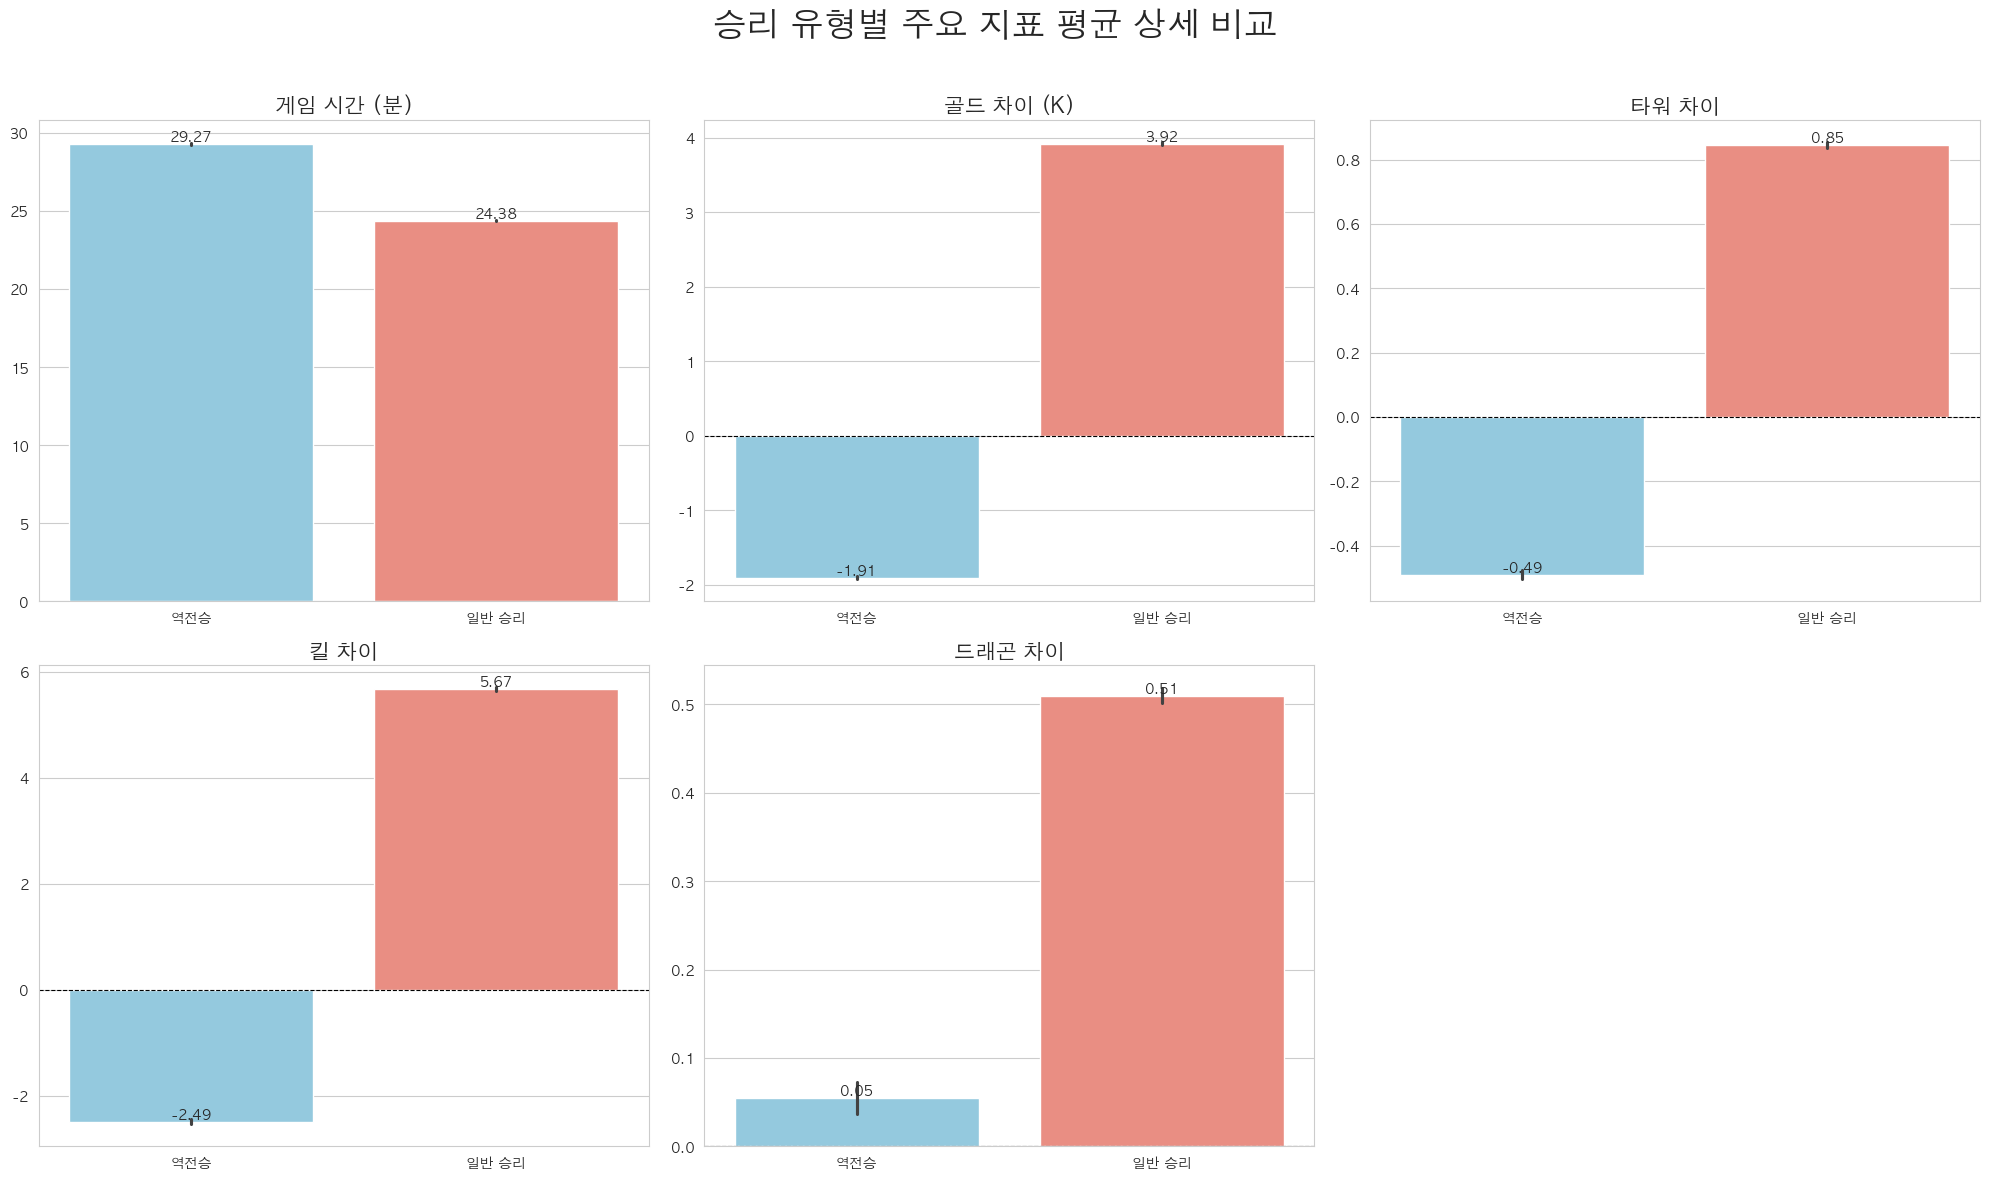

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 역전승 데이터 정의 ---
blue_comeback_condition = (df['blueWins'] == True) & (df['blueTotalGold'] < df['redTotalGold'])
red_comeback_condition = (df['blueWins'] == False) & (df['redTotalGold'] < df['blueTotalGold'])
comeback_condition = blue_comeback_condition | red_comeback_condition

print("--- 1-1. 역전승 비율 분석 ---")
total_comebacks = comeback_condition.sum()
total_games = len(df)
normal_games = total_games - total_comebacks

plt.figure(figsize=(8, 8))
plt.pie([normal_games, total_comebacks], labels=['일반적인 게임', '역전승'], autopct='%.1f%%',
        startangle=90, colors=['skyblue', 'salmon'], textprops={'fontsize': 14})
plt.title('전체 경기 중 역전승 발생 비율', fontsize=18, fontweight='bold')
plt.show()

print("\n--- 1-2. 골드 격차에 따른 역전 확률 ---")
gold_diff_abs = abs(df['blueTotalGold'] - df['redTotalGold'])
gold_bins = pd.cut(gold_diff_abs, bins=range(0, 8001, 1000), right=False)

total_games_by_gold_diff = df.groupby(gold_bins).size()
comeback_games_by_gold_diff = df[comeback_condition].groupby(gold_bins).size()
comeback_chance = (comeback_games_by_gold_diff / total_games_by_gold_diff) * 100

plt.figure(figsize=(14, 8))
ax = sns.barplot(x=comeback_chance.index.astype(str), y=comeback_chance.values, color='salmon')
plt.title('15분 골드 격차별 역전승 확률', fontsize=18, fontweight='bold')
plt.xlabel('골드 격차 (절대값)')
plt.ylabel('역전승 확률 (%)')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- 1-3. 역전승 팀의 평균 열세 정도 ---")
comeback_games_df = df[comeback_condition].copy()
comeback_games_df['gold_deficit'] = np.where(
    blue_comeback_condition[comeback_condition],
    comeback_games_df['blueTotalGold'] - comeback_games_df['redTotalGold'],
    comeback_games_df['redTotalGold'] - comeback_games_df['blueTotalGold']
)

plt.figure(figsize=(12, 7))
sns.histplot(data=comeback_games_df, x='gold_deficit', kde=True, bins=30, color='salmon')
plt.title('역전승 성공 시, 15분 골드 열세 분포', fontsize=18, fontweight='bold')
plt.xlabel('골드 격차 (역전승 팀 - 상대 팀)')
plt.ylabel('게임 수')
avg_deficit = comeback_games_df['gold_deficit'].mean()
plt.axvline(avg_deficit, color='red', linestyle='--', label=f"평균: {avg_deficit:,.0f} 골드")
plt.legend()
plt.show()

print("\n--- 2. 승리 유형별 주요 지표 평균 비교 ---")

normal_win_condition = ((df['blueWins'] == True) & (df['blueTotalGold'] >= df['redTotalGold'])) | \
                       ((df['blueWins'] == False) & (df['redTotalGold'] >= df['blueTotalGold']))

df['win_type'] = np.select(
    [comeback_condition, normal_win_condition],
    ['역전승', '일반 승리'],
    default='패배'
)

win_games_df = df[df['win_type'] != '패배'].copy()

win_games_df['게임 시간 (분)'] = win_games_df['gameDuration'] / 60
win_games_df['골드 차이 (K)'] = np.where(win_games_df['blueWins'], win_games_df['blueTotalGold'] - win_games_df['redTotalGold'], win_games_df['redTotalGold'] - win_games_df['blueTotalGold']) / 1000
win_games_df['타워 차이'] = np.where(win_games_df['blueWins'], win_games_df['blueTowersDestroyed'] - win_games_df['redTowersDestroyed'], win_games_df['redTowersDestroyed'] - win_games_df['blueTowersDestroyed'])
win_games_df['킬 차이'] = np.where(win_games_df['blueWins'], win_games_df['blueKills'] - win_games_df['redKills'], win_games_df['redKills'] - win_games_df['blueKills'])
win_games_df['드래곤 차이'] = np.where(win_games_df['blueWins'], win_games_df['blueDragons'] - win_games_df['redDragons'], win_games_df['redDragons'] - win_games_df['blueDragons'])

metrics_to_plot = ['게임 시간 (분)', '골드 차이 (K)', '타워 차이', '킬 차이', '드래곤 차이']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('승리 유형별 주요 지표 평균 상세 비교', fontsize=24, fontweight='bold')
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    sns.barplot(data=win_games_df, x='win_type', y=metric, ax=ax, palette=['skyblue', 'salmon'])
    ax.set_title(metric, fontsize=15)
    ax.set_xlabel('')
    ax.set_ylabel('')

    if '차이' in metric:
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 5), textcoords='offset points')

for i in range(len(metrics_to_plot), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

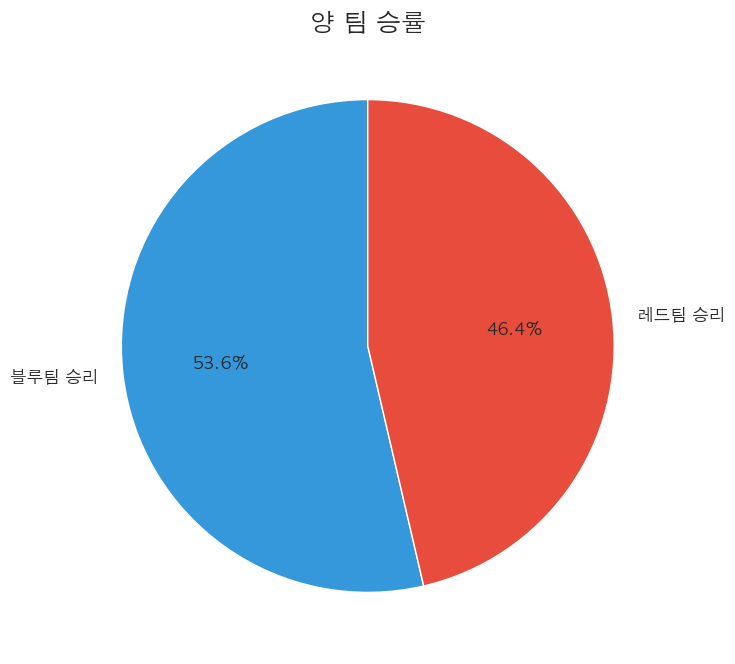

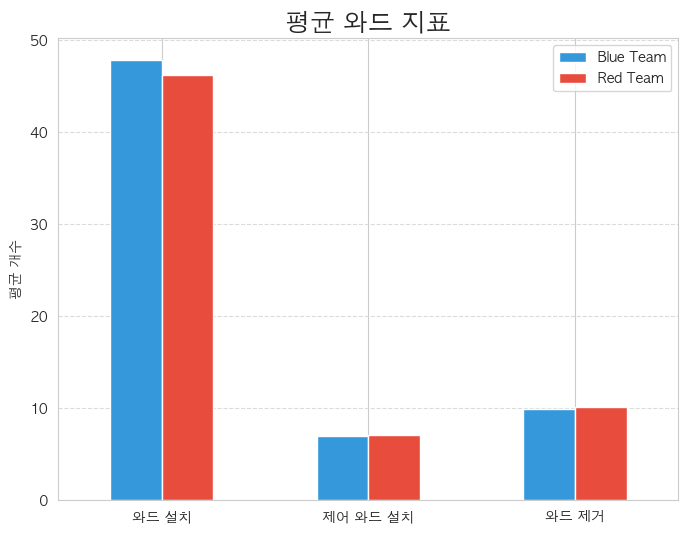

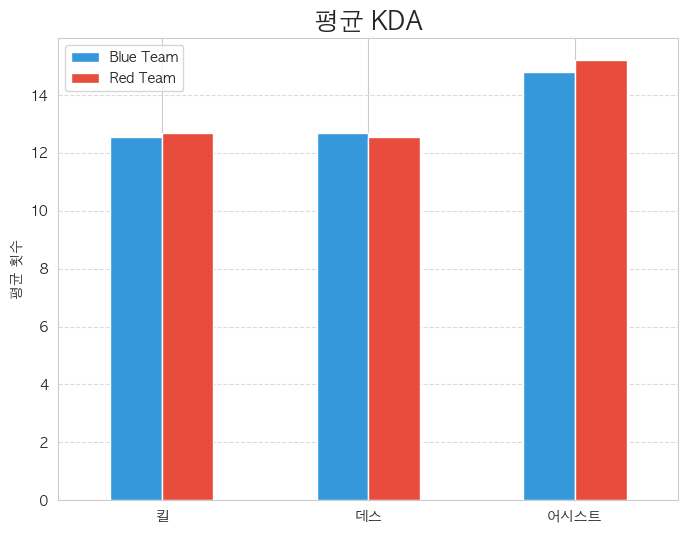

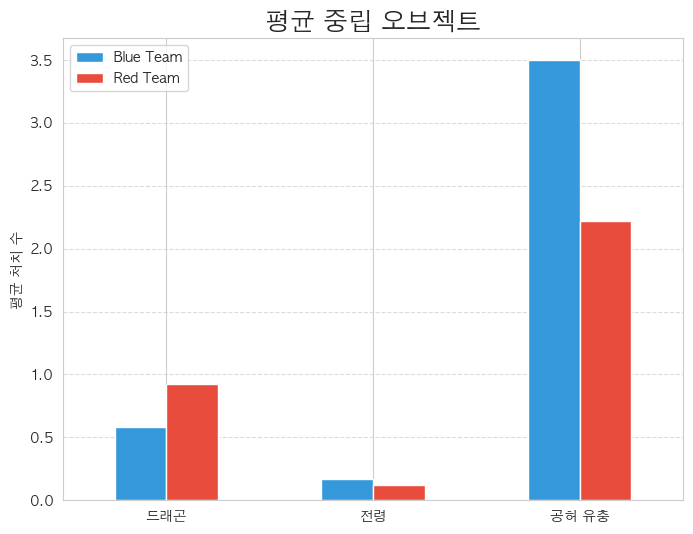

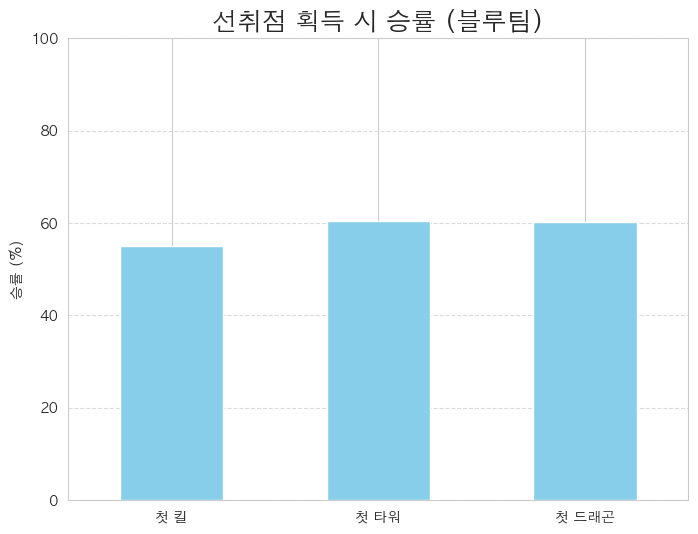

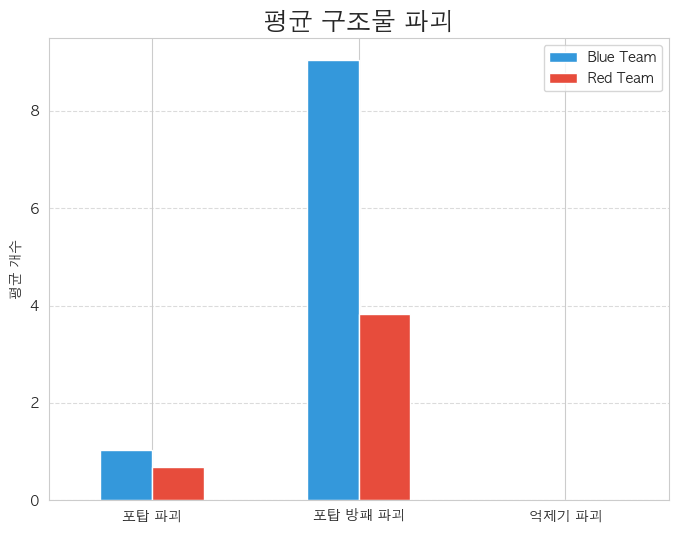

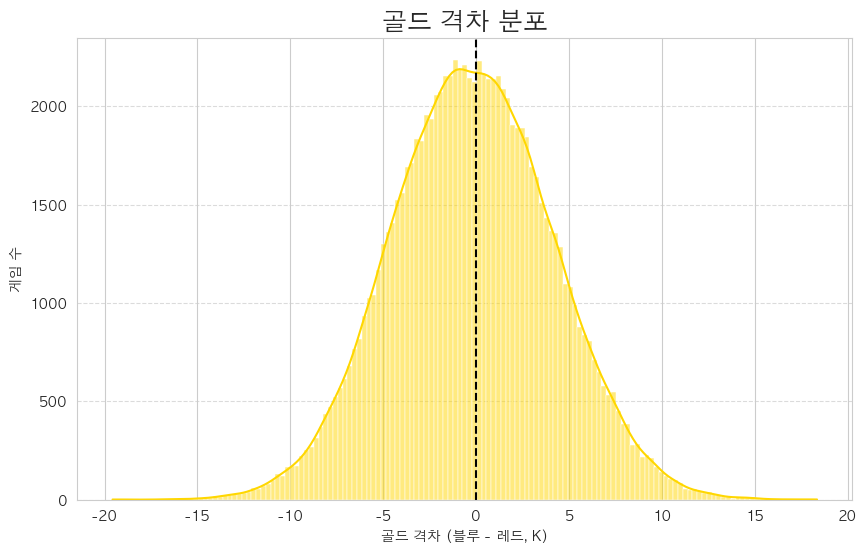

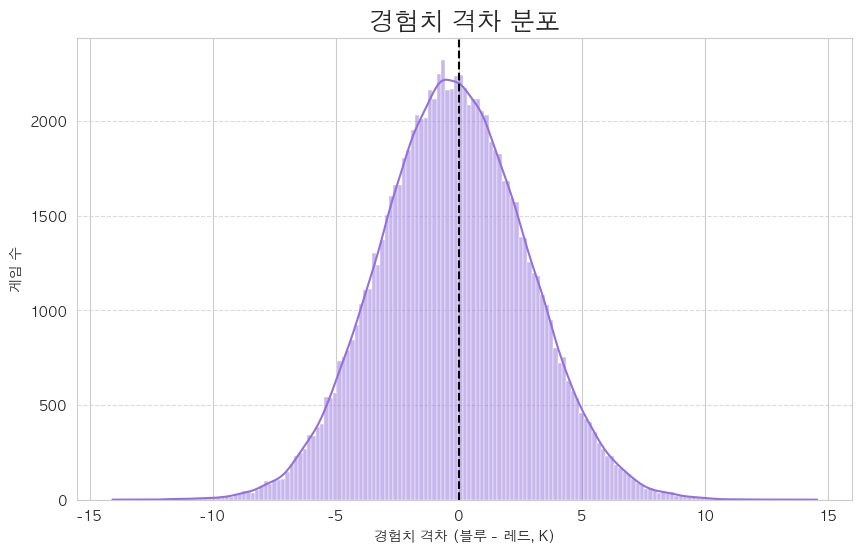

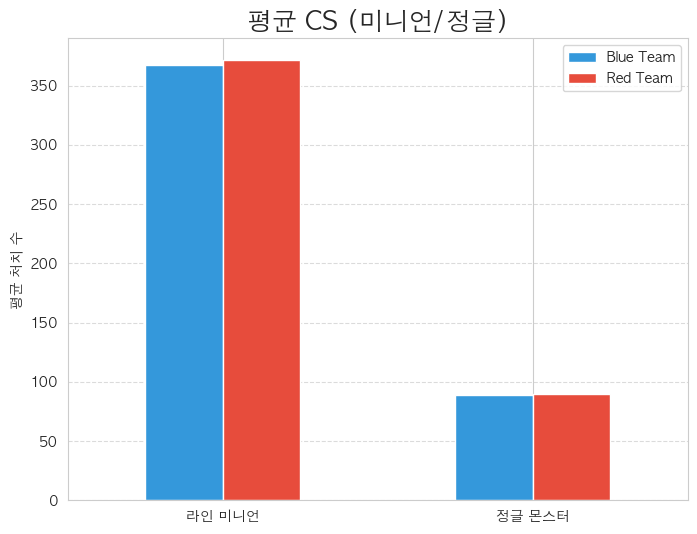

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 양 팀 승률 비교 ---
plt.figure(figsize=(8, 8))
win_counts = df['blueWins'].value_counts()
plt.pie(win_counts, labels=['블루팀 승리', '레드팀 승리'], autopct='%.1f%%',
        startangle=90, colors=['#3498db', '#e74c3c'], textprops={'fontsize': 12})
plt.title('양 팀 승률', fontsize=18, fontweight='bold')
plt.show()

# --- 2. 와드 지표 비교 ---
plt.figure(figsize=(8, 6))
ward_metrics = {'와드 설치': ('blueWardsPlaced', 'redWardsPlaced'),
                '제어 와드 설치': ('blueControlWardsPlaced', 'redControlWardsPlaced'),
                '와드 제거': ('blueWardsDestroyed', 'redWardsDestroyed')}
ward_df = pd.DataFrame({
    'Blue Team': [df[val[0]].mean() for val in ward_metrics.values()],
    'Red Team': [df[val[1]].mean() for val in ward_metrics.values()]
}, index=ward_metrics.keys())
ward_df.plot(kind='bar', color=['#3498db', '#e74c3c'], rot=0, ax=plt.gca())
plt.title('평균 와드 지표', fontsize=18, fontweight='bold')
plt.ylabel('평균 개수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 3. KDA 비교 ---
plt.figure(figsize=(8, 6))
kda_metrics = {'킬': ('blueKills', 'redKills'),
               '데스': ('blueDeaths', 'redDeaths'),
               '어시스트': ('blueAssists', 'redAssists')}
kda_df = pd.DataFrame({
    'Blue Team': [df[val[0]].mean() for val in kda_metrics.values()],
    'Red Team': [df[val[1]].mean() for val in kda_metrics.values()]
}, index=kda_metrics.keys())
kda_df.plot(kind='bar', color=['#3498db', '#e74c3c'], rot=0, ax=plt.gca())
plt.title('평균 KDA', fontsize=18, fontweight='bold')
plt.ylabel('평균 횟수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 4. 중립 오브젝트 비교 ---
plt.figure(figsize=(8, 6))
neutral_obj_metrics = {'드래곤': ('blueDragons', 'redDragons'),
                       '전령': ('blueHeralds', 'redHeralds'),
                       '공허 유충': ('blueVoidGrubs', 'redVoidGrubs')}
neutral_obj_df = pd.DataFrame({
    'Blue Team': [df[val[0]].mean() for val in neutral_obj_metrics.values()],
    'Red Team': [df[val[1]].mean() for val in neutral_obj_metrics.values()]
}, index=neutral_obj_metrics.keys())
neutral_obj_df.plot(kind='bar', color=['#3498db', '#e74c3c'], rot=0, ax=plt.gca())
plt.title('평균 중립 오브젝트', fontsize=18, fontweight='bold')
plt.ylabel('평균 처치 수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 5. 선취점 획득 시 승률 ---
plt.figure(figsize=(8, 6))
fb_win = df.groupby('blueFirstBlood')['blueWins'].mean()[1] * 100
ft_win = df.groupby('blueFirstTurret')['blueWins'].mean()[1] * 100
fd_win = df.groupby('blueFirstDragon')['blueWins'].mean()[1] * 100
first_obj_df = pd.Series({'첫 킬': fb_win, '첫 타워': ft_win, '첫 드래곤': fd_win})
first_obj_df.plot(kind='bar', color='skyblue', rot=0, ax=plt.gca())
plt.title('선취점 획득 시 승률 (블루팀)', fontsize=18, fontweight='bold')
plt.ylabel('승률 (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 6. 구조물 파괴 비교 ---
plt.figure(figsize=(8, 6))
structure_metrics = {'포탑 파괴': ('blueTowersDestroyed', 'redTowersDestroyed'),
                     '포탑 방패 파괴': ('bluePlatesDestroyed', 'redPlatesDestroyed'),
                     '억제기 파괴': ('blueInhibitorsDestroyed', 'redInhibitorsDestroyed')}
structure_df = pd.DataFrame({
    'Blue Team': [df[val[0]].mean() for val in structure_metrics.values()],
    'Red Team': [df[val[1]].mean() for val in structure_metrics.values()]
}, index=structure_metrics.keys())
structure_df.plot(kind='bar', color=['#3498db', '#e74c3c'], rot=0, ax=plt.gca())
plt.title('평균 구조물 파괴', fontsize=18, fontweight='bold')
plt.ylabel('평균 개수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 7. 골드 격차 분포 ---
plt.figure(figsize=(10, 6))
gold_diff = (df['blueTotalGold'] - df['redTotalGold']) / 1000 # K 단위
sns.histplot(gold_diff, kde=True, color='gold')
plt.title('골드 격차 분포', fontsize=18, fontweight='bold')
plt.xlabel('골드 격차 (블루 - 레드, K)')
plt.ylabel('게임 수')
plt.axvline(0, color='black', linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 8. 경험치 격차 분포 ---
plt.figure(figsize=(10, 6))
exp_diff = (df['blueTotalExperience'] - df['redTotalExperience']) / 1000 # K 단위
sns.histplot(exp_diff, kde=True, color='mediumpurple')
plt.title('경험치 격차 분포', fontsize=18, fontweight='bold')
plt.xlabel('경험치 격차 (블루 - 레드, K)')
plt.ylabel('게임 수')
plt.axvline(0, color='black', linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 9. CS 비교 ---
plt.figure(figsize=(8, 6))
minion_metrics = {'라인 미니언': ('blueTotalMinionsKilled', 'redTotalMinionsKilled'),
                  '정글 몬스터': ('blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled')}
minion_df = pd.DataFrame({
    'Blue Team': [df[val[0]].mean() for val in minion_metrics.values()],
    'Red Team': [df[val[1]].mean() for val in minion_metrics.values()]
}, index=minion_metrics.keys())
minion_df.plot(kind='bar', color=['#3498db', '#e74c3c'], rot=0, ax=plt.gca())
plt.title('평균 CS (미니언/정글)', fontsize=18, fontweight='bold')
plt.ylabel('평균 처치 수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




--- 2. 승리 유형별 주요 지표 분포 비교 ---


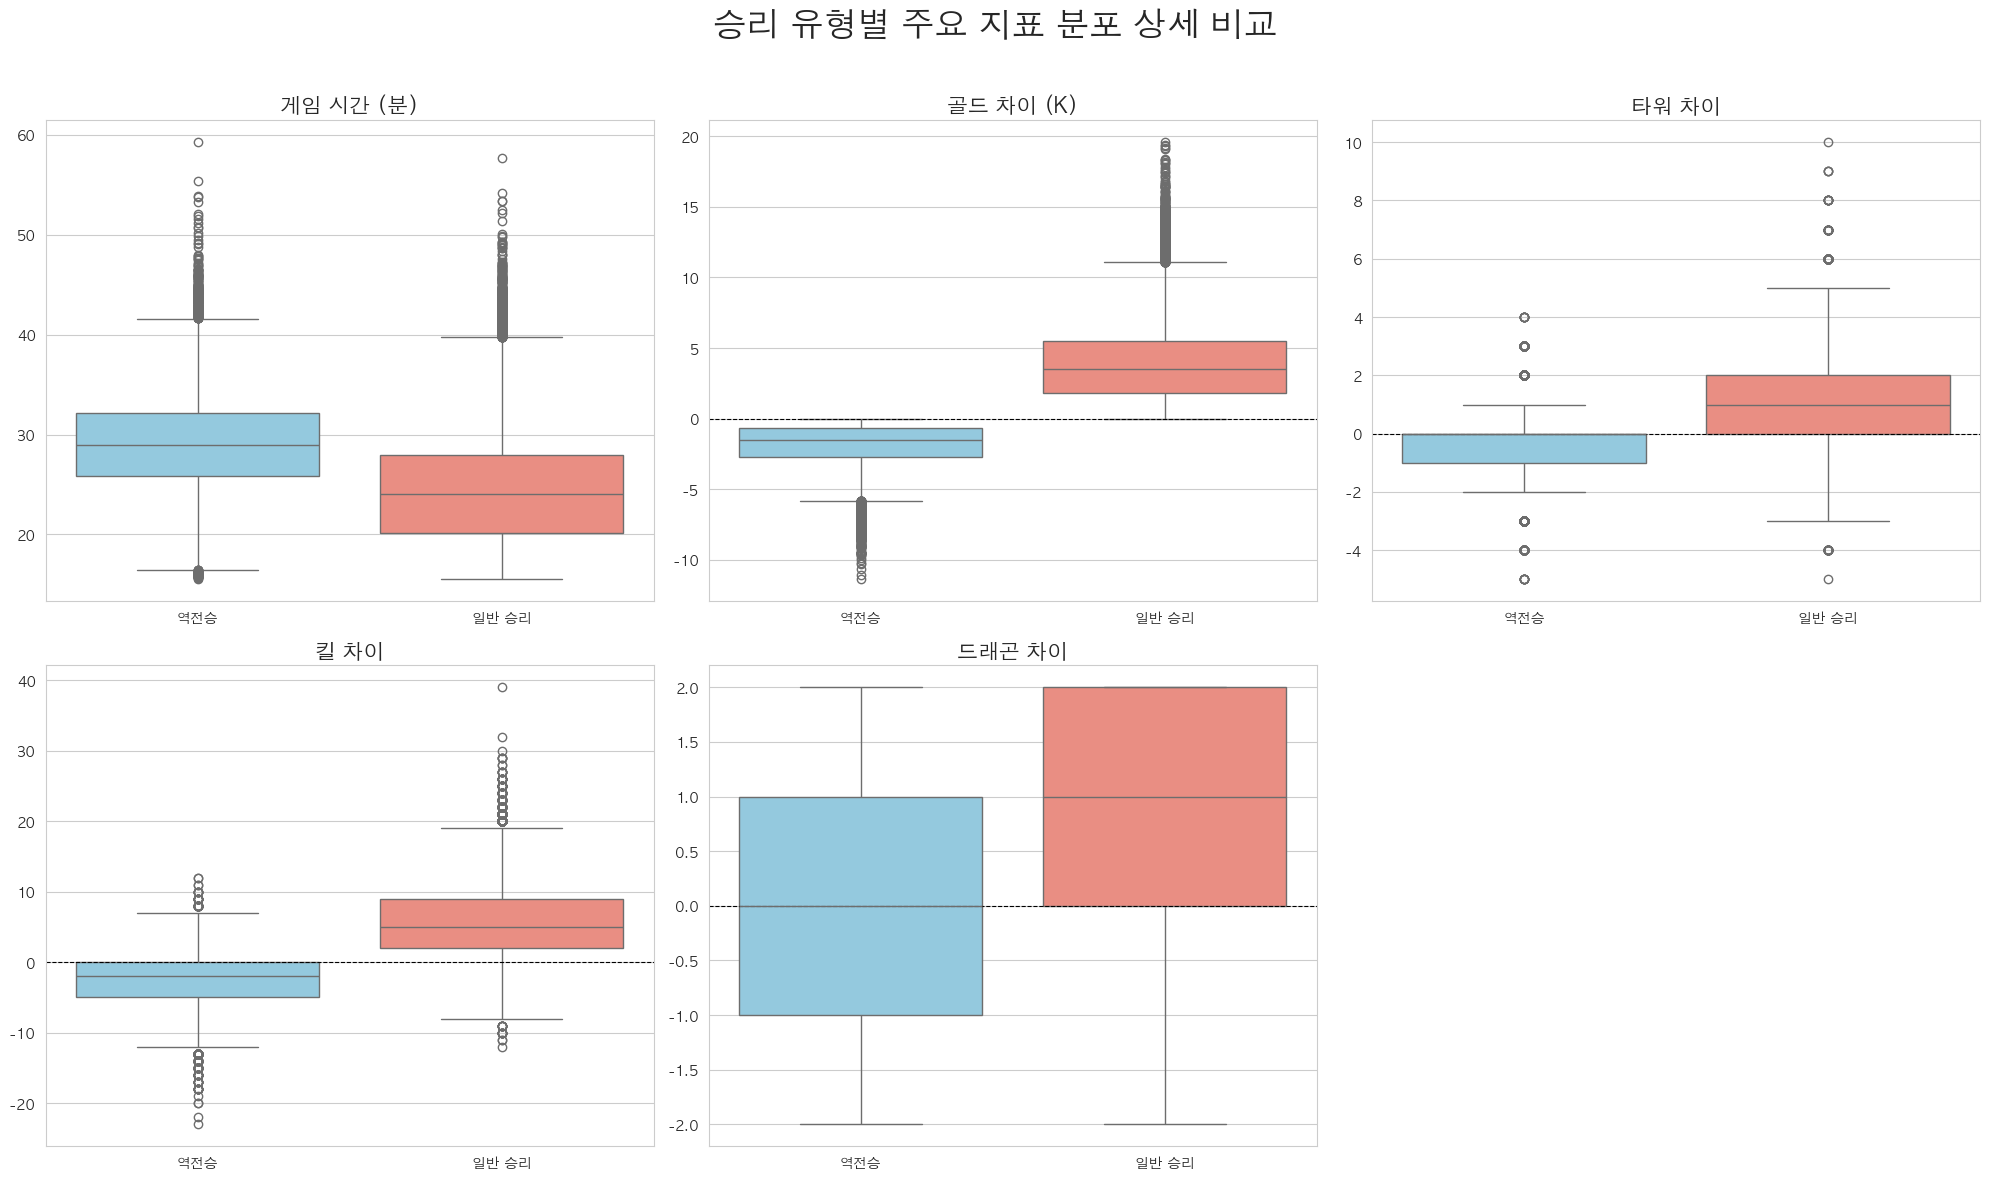

In [10]:
# (이전 데이터 준비 코드는 KIKI님 코드를 그대로 사용한다고 가정)

print("\n--- 2. 승리 유형별 주요 지표 분포 비교 ---") # 제목의 '평균'을 '분포'로 수정

# 분석을 위한 데이터프레임 생성 (이하 KIKI님 코드와 동일)
normal_win_condition = ((df['blueWins'] == True) & (df['blueTotalGold'] >= df['redTotalGold'])) | \
                       ((df['blueWins'] == False) & (df['redTotalGold'] >= df['blueTotalGold']))
df['win_type'] = np.select(
    [comeback_condition, normal_win_condition],
    ['역전승', '일반 승리'],
    default='패배'
)
win_games_df = df[df['win_type'] != '패배'].copy()
win_games_df['게임 시간 (분)'] = win_games_df['gameDuration'] / 60
win_games_df['골드 차이 (K)'] = np.where(win_games_df['blueWins'], win_games_df['blueTotalGold'] - win_games_df['redTotalGold'], win_games_df['redTotalGold'] - win_games_df['blueTotalGold']) / 1000
win_games_df['타워 차이'] = np.where(win_games_df['blueWins'], win_games_df['blueTowersDestroyed'] - win_games_df['redTowersDestroyed'], win_games_df['redTowersDestroyed'] - win_games_df['blueTowersDestroyed'])
win_games_df['킬 차이'] = np.where(win_games_df['blueWins'], win_games_df['blueKills'] - win_games_df['redKills'], win_games_df['redKills'] - win_games_df['blueKills'])
win_games_df['드래곤 차이'] = np.where(win_games_df['blueWins'], win_games_df['blueDragons'] - win_games_df['redDragons'], win_games_df['redDragons'] - win_games_df['blueDragons'])
metrics_to_plot = ['게임 시간 (분)', '골드 차이 (K)', '타워 차이', '킬 차이', '드래곤 차이']


# --- [시각화 코드 수정] ---

# 2x3 그리드로 서브플롯 생성
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('승리 유형별 주요 지표 분포 상세 비교', fontsize=24, fontweight='bold') # 제목 수정
axes = axes.flatten()

# 각 지표별로 박스 플롯(boxplot) 생성
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    # sns.barplot -> sns.boxplot 으로 변경
    sns.boxplot(data=win_games_df, x='win_type', y=metric, ax=ax, palette=['skyblue', 'salmon'])
    ax.set_title(metric, fontsize=15)
    ax.set_xlabel('')
    ax.set_ylabel('')

    # '차이'가 들어간 그래프에 0점선 추가
    if '차이' in metric:
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        
    # 박스 플롯은 분포를 나타내므로, 단일 값 표기 부분은 제거합니다.

# 남는 서브플롯 숨기기
for i in range(len(metrics_to_plot), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()